In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from visions.backends.python.types import time

# from ydata_profiling import ProfileReport
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

df=pd.read_csv("C:/Users/yahia/PycharmProjects/JupyterProject3/data/HousingData.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992    0.069959    0.554695   

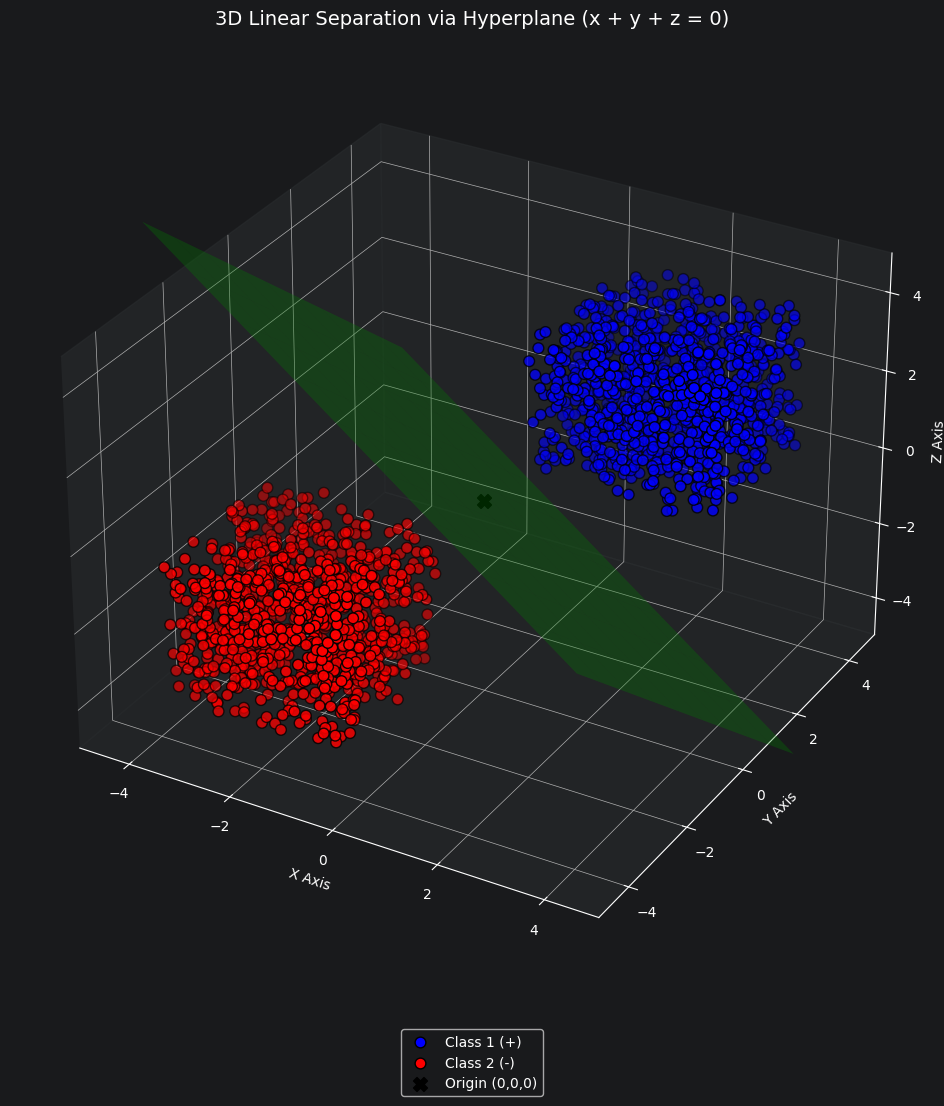

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Generate linearly separable random 3D data points
np.random.seed(42)
class1 = np.random.uniform(0.5, 4.0, (1000, 30))    # Clustered in positive region
class2 = np.random.uniform(-4.0, -0.5, (1000, 30))  # Clustered in negative region

# 2. Define the separating hyperplane: x + y + z = 0 -> z = -x - y
# Create a grid of x and y values to plot the surface sheet
x_range = np.linspace(-4, 4, 10)
y_range = np.linspace(-4, 4, 10)
X, Y = np.meshgrid(x_range, y_range)
Z = -X - Y

# 3. Initialize the 3D plotting environment
fig = plt.figure(figsize=(20, 12))
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the data points
ax.scatter(class1[:, 0], class1[:, 1], class1[:, 2],
           color='blue', label='Class 1 (+)', s=60, edgecolors='k')
ax.scatter(class2[:, 0], class2[:, 1], class2[:, 2],
           color='red', label='Class 2 (-)', s=60, edgecolors='k')

# 5. Plot the separating hyperplane sheet
surface = ax.plot_surface(X, Y, Z, color='green', alpha=0.3, shade=False)
surface._facecolors2d = surface._edgecolors2d = None  # Fix for matplotlib legend bug

# 6. Customize graph labels, limits, and view options
ax.set_title('3D Linear Separation via Hyperplane (x + y + z = 0)', fontsize=14, pad=20)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-5, 5])

# Add a visual indicator for the origin point
ax.scatter([0], [0], [0], color='black', s=100, marker='X', label='Origin (0,0,0)')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),)
plt.show()


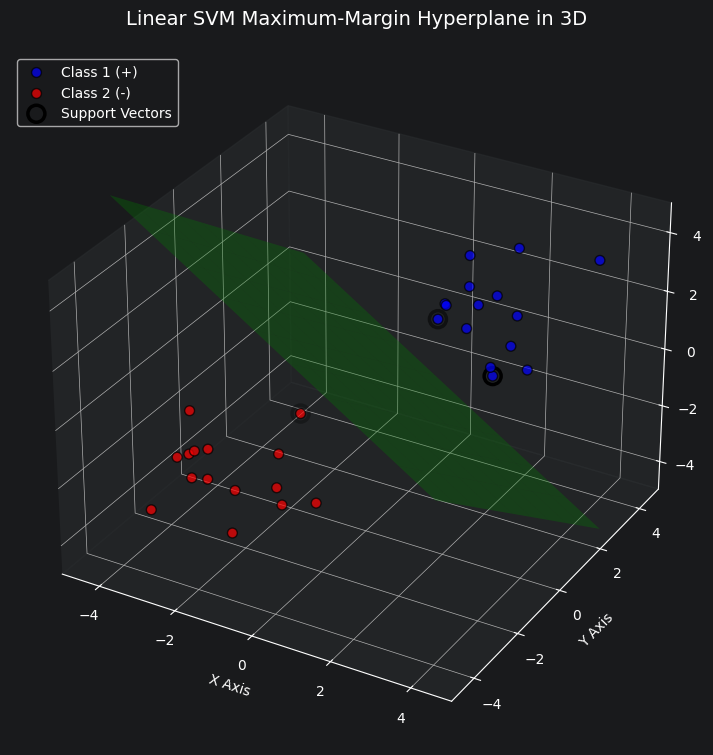

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from mpl_toolkits.mplot3d import Axes3D

# 1. Generate linearly separable random 3D data points
np.random.seed(42)
class1 = np.random.uniform(0.5, 4.0, (15, 3))    # Clustered in positive region
class2 = np.random.uniform(-4.0, -0.5, (15, 3))  # Clustered in negative region

# Combine into training features (X) and target labels (y)
X = np.vstack((class1, class2))
y = np.hstack((np.ones(15), np.zeros(15)))  # 1 for Class 1, 0 for Class 2

# 2. Train a Linear Support Vector Machine
clf = SVC(kernel='linear', C=1.0)
clf.fit(X, y)

# Extract hyperplane parameters: w1*x + w2*y + w3*z + b = 0
w = clf.coef_[0]
b = clf.intercept_[0]

# 3. Create a grid surface for the optimal hyperplane sheet
# Rearranging the equation for Z: z = (-w1*x - w2*y - b) / w3
x_range = np.linspace(-4, 4, 10)
y_range = np.linspace(-4, 4, 10)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = (-w[0] * X_grid - w[1] * Y_grid - b) / w[2]

# 4. Initialize the 3D plotting environment
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 5. Plot the standard data points
ax.scatter(class1[:, 0], class1[:, 1], class1[:, 2],
           color='blue', label='Class 1 (+)', s=50, alpha=0.7, edgecolors='k')
ax.scatter(class2[:, 0], class2[:, 1], class2[:, 2],
           color='red', label='Class 2 (-)', s=50, alpha=0.7, edgecolors='k')

# 6. Highlight the critical Support Vectors chosen by scikit-learn
sv = clf.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], sv[:, 2], s=150,
           facecolors='none', edgecolors='black', linewidths=2.5, label='Support Vectors')

# 7. Render the optimal SVM maximum-margin hyperplane
surface = ax.plot_surface(X_grid, Y_grid, Z_grid, color='green', alpha=0.3, shade=False)
surface._facecolors2d = surface._edgecolors2d = None  # Matplotlib legend fix

# 8. Design and label configurations
ax.set_title('Linear SVM Maximum-Margin Hyperplane in 3D', fontsize=14, pad=20)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-5, 5])

ax.legend(loc='upper left')
plt.show()
